In [1]:
# Install yfinance if not already installed
!pip install yfinance

# Import podstawowych bibliotek analitycznych
import pandas as pd
import numpy as np

# Import biblioteki do pobierania danych giełdowych z Yahoo Finance
import yfinance as yf

# Import bibliotek do wizualizacji danych (przygotowanie pod wykresy i heatmapy)
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie estetycznego stylu dla przyszłych wykresów
sns.set_theme(style="whitegrid")

In [2]:
# 1. Definiowanie ram czasowych i tickerów giełdowych
start_date = "2020-01-03"
end_date = "2026-05-01"

# Słownik tickerów: Klucz to symbol na Yahoo Finance, Wartość to nasza nazwa kolumny
tickers_dict = {
    "BTC-USD": "Bitcoin",
    "GC=F": "Zloto",       # Zmieniony ticker na stabilne kontrakty (Gold Futures)
    "^GSPC": "SP500"
}

# 2. Pobieranie cen zamknięcia ('Close')
print("Pobieranie danych z Yahoo Finance...")
df_prices = yf.download(list(tickers_dict.keys()), start=start_date, end=end_date)['Close']

# Zmiana nazw kolumn na czytelniejsze dla modelu
df_prices.rename(columns=tickers_dict, inplace=True)

# 3. Synchronizacja do interwału tygodniowego (ceny z piątku) i czyszczenie braków
# 'W-FRI' oznacza Weekly (Friday)
df_weekly_prices = df_prices.resample('W-FRI').last()

# Usunięcie wierszy z wartościami NaN (np. brak notowań w święta)
df_weekly_prices = df_weekly_prices.dropna()

print("\nPodgląd zsynchronizowanych cen surowych:")
display(df_weekly_prices.head())

Pobieranie danych z Yahoo Finance...


[*********************100%***********************]  3 of 3 completed


Podgląd zsynchronizowanych cen surowych:


Ticker,Bitcoin,Zloto,SP500
Date,,,
2020-01-03,7344.884277,1549.199951,3234.850098
2020-01-10,8166.554199,1557.500000,3265.350098
2020-01-17,8929.038086,1558.800049,3329.620117
2020-01-24,8445.434570,1571.099976,3295.469971
2020-01-31,9350.529297,1582.900024,3225.520020


In [3]:
# 4. Obliczenie logarytmicznych stóp zwrotu
# Wzór: ln(cena z dzisiaj / cena z poprzedniego tygodnia)
df_returns = np.log(df_weekly_prices / df_weekly_prices.shift(1))

# Przesunięcie o 1 tydzień (.shift(1)) sprawia, że pierwszy wiersz staje się pusty (NaN)
# Musimy go usunąć
df_returns = df_returns.dropna()

print("Podgląd logarytmicznych stóp zwrotu (gotowych do modelu):")
display(df_returns.head())

Podgląd logarytmicznych stóp zwrotu (gotowych do modelu):


Ticker,Bitcoin,Zloto,SP500
Date,,,
2020-01-10,0.106043,0.005343,0.009384
2020-01-17,0.089262,0.000834,0.019491
2020-01-24,-0.055683,0.007860,-0.010309
2020-01-31,0.101807,0.007483,-0.021455
2020-02-07,0.046535,-0.009075,0.031190


Macierz korelacji Pearsona:


Ticker,Bitcoin,Zloto,SP500
Ticker,,,
Bitcoin,1.000000,0.133170,0.278343
Zloto,0.133170,1.000000,0.257266
SP500,0.278343,0.257266,1.000000


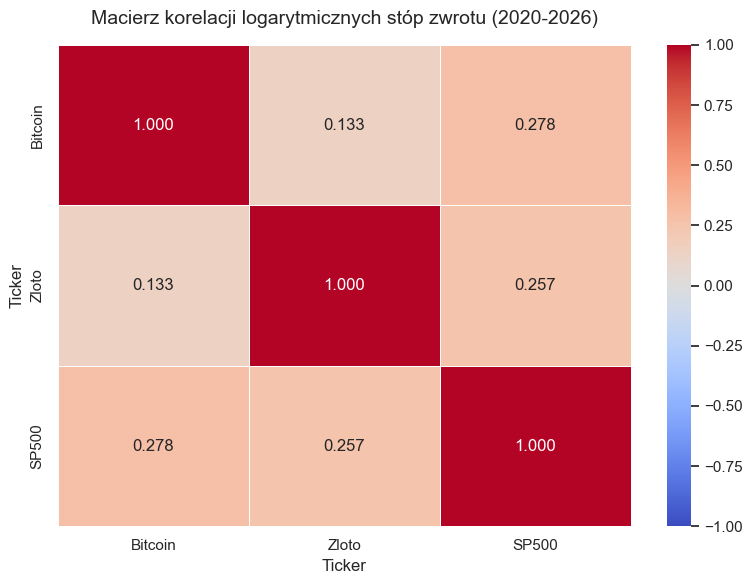

In [4]:
# 5. Wyliczenie macierzy korelacji Pearsona
correlation_matrix = df_returns.corr(method='pearson')

# Wyświetlenie surowej macierzy w konsoli
print("Macierz korelacji Pearsona:")
display(correlation_matrix)

# 6. Rysowanie heatmapy (mapy ciepła) korelacji
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(
    correlation_matrix, 
    annot=True,              # Wyświetlanie wartości liczbowych na wykresie
    cmap='coolwarm',         # Kolorystyka: niebieski dla ujemnych, czerwony dla dodatnich
    vmin=-1, vmax=1,         # Zakres korelacji od -1 do 1
    fmt=".3f",               # Trzy miejsca po przecinku
    linewidths=0.5
)

plt.title('Macierz korelacji logarytmicznych stóp zwrotu (2020-2026)', fontsize=14, pad=15)
plt.tight_layout()

# Zapisanie wykresu do pliku graficznego (do wklejenia w Wordzie)
plt.savefig('korelacja_heatmap.png', dpi=300)
plt.show()

In [5]:
from scipy import stats

# Obliczanie p-value dla pary Bitcoin - S&P 500
corr_sp500, p_value_sp500 = stats.pearsonr(df_returns['Bitcoin'], df_returns['SP500'])
print(f"Korelacja BTC vs S&P500: {corr_sp500:.3f} (p-value: {p_value_sp500:.4f})")

# Obliczanie p-value dla pary Bitcoin - Złoto
corr_gold, p_value_gold = stats.pearsonr(df_returns['Bitcoin'], df_returns['Zloto'])
print(f"Korelacja BTC vs Złoto: {corr_gold:.3f} (p-value: {p_value_gold:.4f})")

Korelacja BTC vs S&P500: 0.278 (p-value: 0.0000)
Korelacja BTC vs Złoto: 0.133 (p-value: 0.0155)


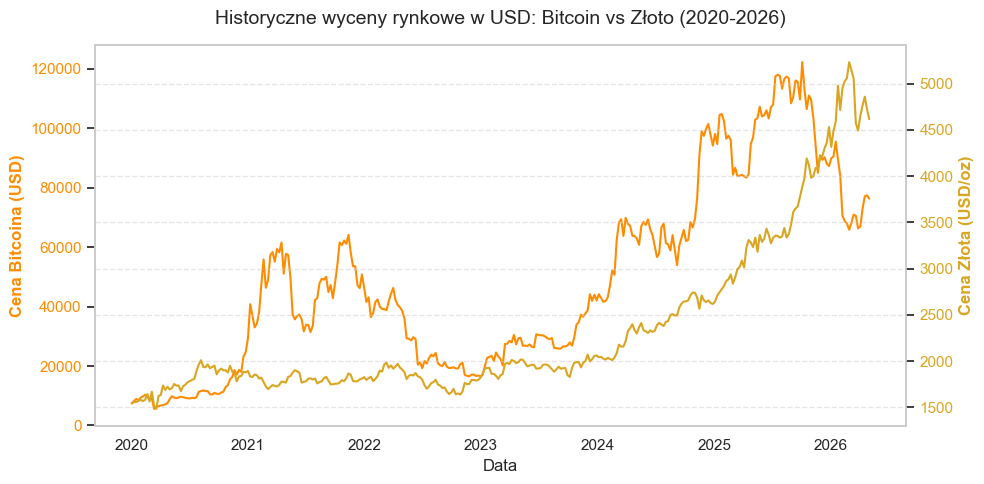

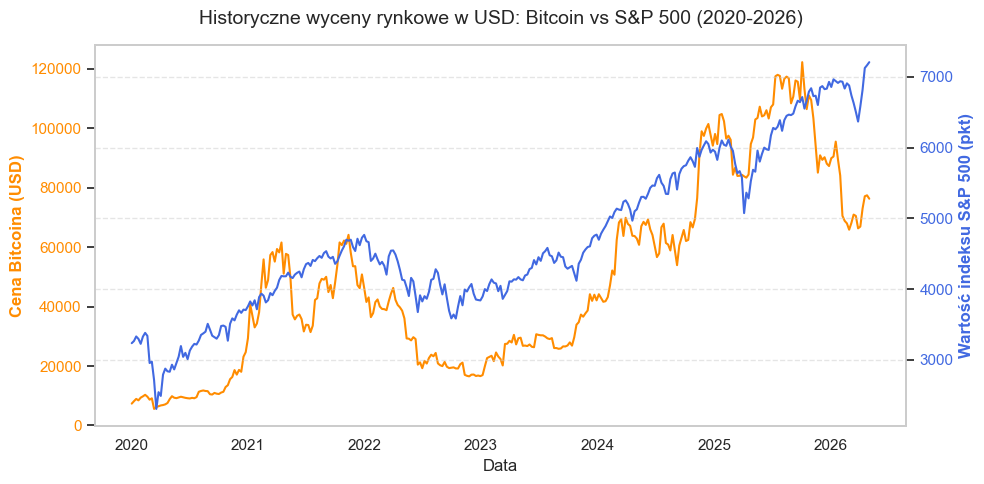

In [6]:
# ==========================================
# 1. CENY HISTORYCZNE W USD: BITCOIN VS ZŁOTO
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Oś lewa dla Bitcoina
color1 = 'darkorange'
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Cena Bitcoina (USD)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_weekly_prices.index, df_weekly_prices['Bitcoin'], color=color1, linewidth=1.5, label='Bitcoin')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(False) # Wyłączamy siatkę na lewej osi, żeby uniknąć nałożenia się kresek

# Tworzenie drugiej osi dzielącej tę samą oś X
ax2 = ax1.twinx()  

# Oś prawa dla Złota
color2 = 'goldenrod'
ax2.set_ylabel('Cena Złota (USD/oz)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_weekly_prices.index, df_weekly_prices['Zloto'], color=color2, linewidth=1.5, label='Złoto (GC=F)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.title('Historyczne wyceny rynkowe w USD: Bitcoin vs Złoto (2020-2026)', fontsize=14, pad=15)
fig.tight_layout() 
plt.savefig('cena_usd_btc_zloto.png', dpi=300)
plt.show()

# ==========================================
# 2. CENY HISTORYCZNE W USD: BITCOIN VS S&P 500
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Oś lewa dla Bitcoina
color1 = 'darkorange'
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Cena Bitcoina (USD)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_weekly_prices.index, df_weekly_prices['Bitcoin'], color=color1, linewidth=1.5, label='Bitcoin')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(False)

# Tworzenie drugiej osi
ax2 = ax1.twinx()  

# Oś prawa dla S&P 500
color2 = 'royalblue'
ax2.set_ylabel('Wartość indeksu S&P 500 (pkt)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_weekly_prices.index, df_weekly_prices['SP500'], color=color2, linewidth=1.5, label='S&P 500')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.title('Historyczne wyceny rynkowe w USD: Bitcoin vs S&P 500 (2020-2026)', fontsize=14, pad=15)
fig.tight_layout() 
plt.savefig('cena_usd_btc_sp500.png', dpi=300)
plt.show()

In [7]:
!pip install pandas-datareader

In [8]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

print("Rozpoczynam agregację wszystkich danych...")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0'}

# ==========================================
# 1. PODAŻ PIENIĄDZA M2 (Z PLIKU LOKALNEGO)
# ==========================================
print("Ładowanie prawdziwych danych M2 z odpowiedniego arkusza...")
df_m2 = pd.read_excel('m2_data.xlsx', sheet_name='Weekly, Ending Monday')
df_m2.columns = ['Date', 'M2']
df_m2['Date'] = pd.to_datetime(df_m2['Date'])
df_m2.set_index('Date', inplace=True)

# Filtrowanie i ujednolicenie do interwału tygodniowego (piątki)
df_m2 = df_m2.loc[start_date:end_date]
df_m2_weekly = df_m2.resample('W-FRI').last()
print("✓ Pobrano: Podaż pieniądza M2 (Excel)")

# ==========================================
# 2. HASHRATE BITCOINA (Blockchain.com)
# ==========================================
hash_url = "https://api.blockchain.info/charts/hash-rate?timespan=all&format=csv"
response_hash = requests.get(hash_url, headers=headers, timeout=60)
df_hash = pd.read_csv(StringIO(response_hash.text), header=None, names=['Date', 'Hashrate'])
df_hash['Date'] = pd.to_datetime(df_hash['Date'])
df_hash.set_index('Date', inplace=True)
df_hash = df_hash.loc[start_date:end_date]
df_hash_weekly = df_hash.resample('W-FRI').last()
print("✓ Pobrano: Hashrate (Blockchain.com)")

# ==========================================
# 3. CRYPTO FEAR & GREED INDEX (Alternative.me)
# ==========================================
fng_url = "https://api.alternative.me/fng/?limit=0"
response_fng = requests.get(fng_url, timeout=60)
fng_data = response_fng.json()['data']
df_fng = pd.DataFrame(fng_data)

# Dodane .astype(int) aby zlikwidować FutureWarning
df_fng['Date'] = pd.to_datetime(df_fng['timestamp'].astype(int), unit='s')
df_fng.set_index('Date', inplace=True)
df_fng['Fear_Greed'] = df_fng['value'].astype(float)
df_fng = df_fng.sort_index().loc[start_date:end_date]
df_fng_weekly = df_fng[['Fear_Greed']].resample('W-FRI').last()
print("✓ Pobrano: Fear & Greed Index (Alternative.me)")

# ==========================================
# 4. ŁĄCZENIE I TRANSFORMACJA W MACIERZ
# ==========================================
# Łączenie w jedną tabelę
df_model_raw = pd.concat([df_weekly_prices['Bitcoin'], df_m2_weekly, df_hash_weekly, df_fng_weekly], axis=1)
df_model_raw.dropna(inplace=True)

# Obliczanie logarytmicznych stóp zwrotu i przyrostów
df_model = pd.DataFrame()
df_model['BTC_Return'] = np.log(df_model_raw['Bitcoin'] / df_model_raw['Bitcoin'].shift(1))
df_model['M2_Return'] = np.log(df_model_raw['M2'] / df_model_raw['M2'].shift(1))
df_model['Hashrate_Return'] = np.log(df_model_raw['Hashrate'] / df_model_raw['Hashrate'].shift(1))
df_model['FNG_Change'] = df_model_raw['Fear_Greed'] - df_model_raw['Fear_Greed'].shift(1)

df_model.dropna(inplace=True)

print("\n--- SUKCES: GOTOWA MACIERZ DANYCH DO MODELU KMNK ---")
display(df_model.head())

Rozpoczynam agregację wszystkich danych...
Ładowanie prawdziwych danych M2 z odpowiedniego arkusza...
✓ Pobrano: Podaż pieniądza M2 (Excel)
✓ Pobrano: Hashrate (Blockchain.com)
✓ Pobrano: Fear & Greed Index (Alternative.me)

--- SUKCES: GOTOWA MACIERZ DANYCH DO MODELU KMNK ---


,BTC_Return,M2_Return,Hashrate_Return,FNG_Change
Date,,,,
2020-01-17,0.089262,-0.001966,-0.025748,13.0
2020-01-24,-0.055683,-0.002946,0.140106,-14.0
2020-01-31,0.101807,-0.007247,0.045621,15.0
2020-02-07,0.046535,0.004221,-0.115382,1.0
2020-02-14,0.051351,0.000279,0.066291,7.0


In [9]:
# Import biblioteki do zaawansowanej ekonometrii
import statsmodels.api as sm

print("Budowa modelu regresji KMNK...")

# 1. Zdefiniowanie zmiennej objaśnianej (Y) - to, co chcemy przewidzieć (stopy zwrotu BTC)
Y = df_model['BTC_Return']

# 2. Zdefiniowanie zmiennych objaśniających (X) - czynniki, które badamy
X = df_model[['M2_Return', 'Hashrate_Return', 'FNG_Change']]

# 3. Dodanie wyrazu wolnego (stałej) do macierzy X
# W ekonometrii to absolutny wymóg, aby linia regresji nie musiała przechodzić przez punkt (0,0)
X = sm.add_constant(X)

# 4. Estymacja modelu Klasyczną Metodą Najmniejszych Kwadratów (Ordinary Least Squares - OLS)
model = sm.OLS(Y, X).fit()

# 5. Wyświetlenie pełnej, akademickiej tabeli wyników
print(model.summary())

Budowa modelu regresji KMNK...
                            OLS Regression Results                            
Dep. Variable:             BTC_Return   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     55.83
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           3.93e-29
Time:                        17:22:51   Log-Likelihood:                 413.09
No. Observations:                 329   AIC:                            -818.2
Df Residuals:                     325   BIC:                            -803.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const      

Generowanie wykresów diagnostycznych ACF i PACF...


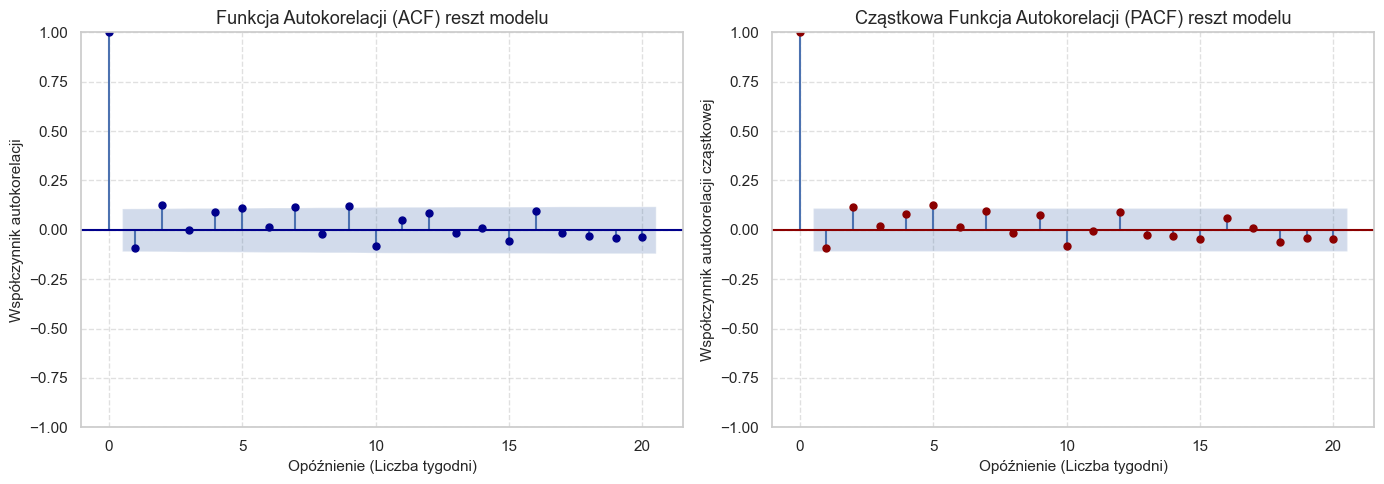

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("Generowanie wykresów diagnostycznych ACF i PACF...")

# Wyciągamy reszty (błędy prognostyczne) z naszego modelu estymowanego w poprzedniej komórce
reszty = model.resid

# Ustawienie rozmiaru głównego okna dla dwóch wykresów obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 1. Wykres ACF (Funkcja Autokorelacji)
# ==========================================
# Badamy wpływ do 20 tygodni wstecz (lags=20), przedział ufności 95% (alpha=0.05)
plot_acf(reszty, ax=axes[0], lags=20, alpha=0.05, color='darkblue')
axes[0].set_title('Funkcja Autokorelacji (ACF) reszt modelu', fontsize=13)
axes[0].set_xlabel('Opóźnienie (Liczba tygodni)', fontsize=11)
axes[0].set_ylabel('Współczynnik autokorelacji', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# ==========================================
# 2. Wykres PACF (Cząstkowa Funkcja Autokorelacji)
# ==========================================
plot_pacf(reszty, ax=axes[1], lags=20, alpha=0.05, color='darkred')
axes[1].set_title('Cząstkowa Funkcja Autokorelacji (PACF) reszt modelu', fontsize=13)
axes[1].set_xlabel('Opóźnienie (Liczba tygodni)', fontsize=11)
axes[1].set_ylabel('Współczynnik autokorelacji cząstkowej', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('acf_pacf_reszty.png', dpi=300)
plt.show()

Generowanie wykresu wartości rzeczywistych vs wyestymowanych...


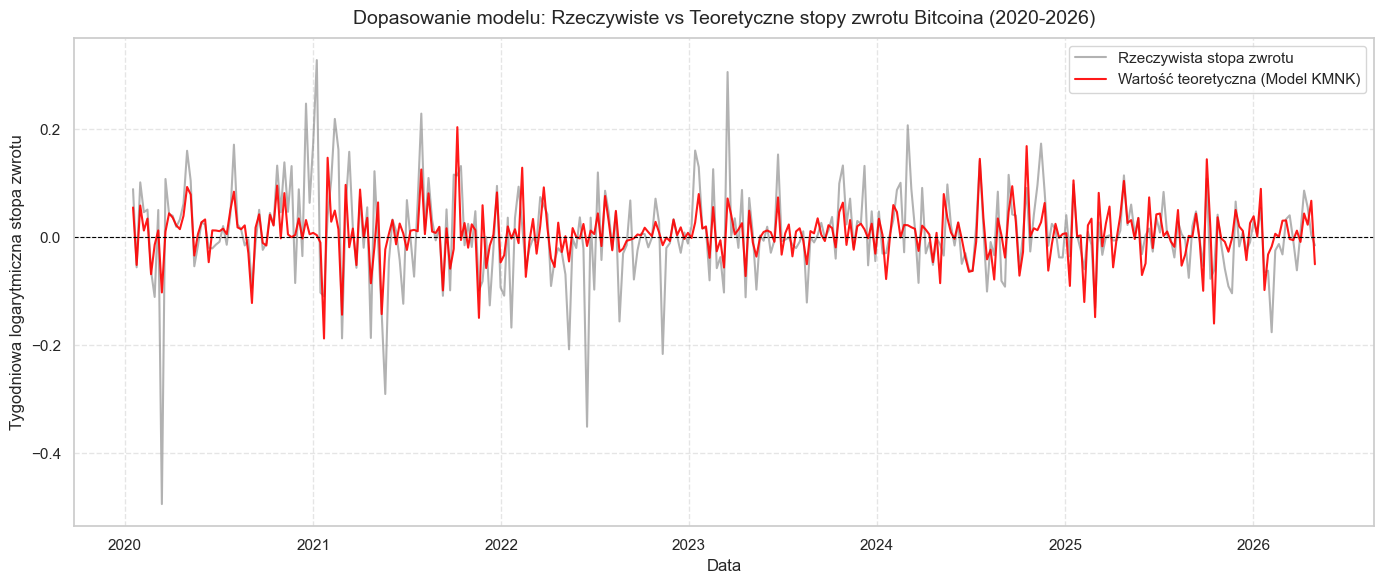

In [11]:
import matplotlib.pyplot as plt

print("Generowanie wykresu wartości rzeczywistych vs wyestymowanych...")

plt.figure(figsize=(14, 6))

# Wartości rzeczywiste (faktyczne stopy zwrotu z rynku)
plt.plot(df_model.index, df_model['BTC_Return'], label='Rzeczywista stopa zwrotu', color='gray', alpha=0.6, linewidth=1.5)

# Wartości teoretyczne (wyliczone przez nasz model KMNK)
plt.plot(df_model.index, model.fittedvalues, label='Wartość teoretyczna (Model KMNK)', color='red', alpha=0.9, linewidth=1.5)

plt.title('Dopasowanie modelu: Rzeczywiste vs Teoretyczne stopy zwrotu Bitcoina (2020-2026)', fontsize=14, pad=10)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Tygodniowa logarytmiczna stopa zwrotu', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Linia zera
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('dopasowanie_modelu.png', dpi=300)
plt.show()

Generowanie ścieżki cenowej w USD...


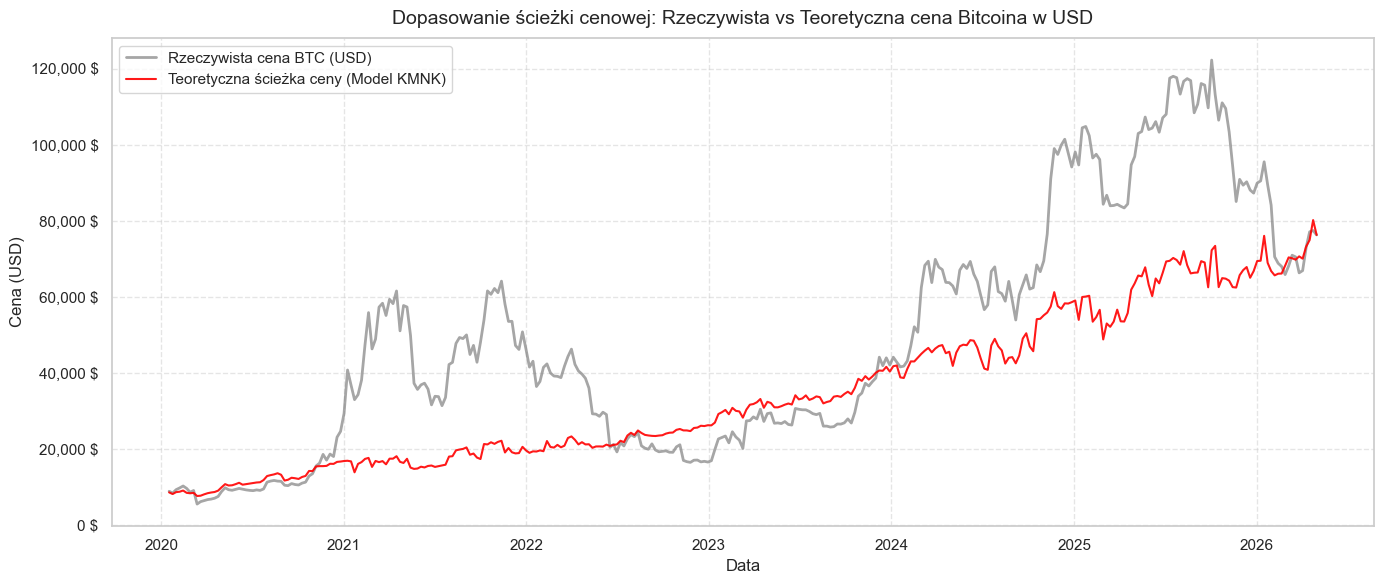

In [12]:
import matplotlib.pyplot as plt
import numpy as np

print("Generowanie ścieżki cenowej w USD...")

# 1. Pobranie rzeczywistych cen z naszej surowej macierzy
ceny_rzeczywiste = df_model_raw.loc[df_model.index, 'Bitcoin']

# 2. Matematyczna rekonstrukcja ceny z modelu
# Bierzemy cenę z pierwszego badanego tygodnia
cena_poczatkowa = df_model_raw['Bitcoin'].iloc[0]

# Odwracamy logarytmiczne stopy zwrotu funkcją exp() na skumulowanej sumie
ceny_teoretyczne = cena_poczatkowa * np.exp(model.fittedvalues.cumsum())

# 3. Rysowanie wykresu
plt.figure(figsize=(14, 6))

plt.plot(ceny_rzeczywiste.index, ceny_rzeczywiste, label='Rzeczywista cena BTC (USD)', color='gray', alpha=0.7, linewidth=2)
plt.plot(ceny_teoretyczne.index, ceny_teoretyczne, label='Teoretyczna ścieżka ceny (Model KMNK)', color='red', alpha=0.9, linewidth=1.5)

plt.title('Dopasowanie ścieżki cenowej: Rzeczywista vs Teoretyczna cena Bitcoina w USD', fontsize=14, pad=10)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Cena (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Formatowanie osi Y, żeby pokazywała dolary zamiast dziwnych ułamków
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f} $'))

plt.tight_layout()
plt.savefig('dopasowanie_cen_usd.png', dpi=300)
plt.show()

In [17]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import jarque_bera

print("--- FORMALNA DIAGNOSTYKA MODELU ---")

# 1. Test Breuscha-Godfreya (Autokorelacja reszt)
bg_test = acorr_breusch_godfrey(model, nlags=4)
print(f"1. Test Breuscha-Godfreya (p-value): {bg_test[1]:.4f}")

# 2. Test Breuscha-Pagana (Homoskedastyczność / stałość wariancji)
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"2. Test Breuscha-Pagana (p-value): {bp_test[1]:.4f}")

# 3. Test White'a (Homoskedastyczność - ujęcie ogólne/nieliniowe)
white_test = het_white(model.resid, model.model.exog)
print(f"3. Test White'a (p-value): {white_test[1]:.4f}")

# 4. Test Jarque-Bera (Normalność rozkładu reszt)
jb_test = jarque_bera(model.resid)
print(f"4. Test Jarque-Bera (p-value): {jb_test[1]:.4f}")

# 5. Test Współliniowości (VIF)
vif_data = pd.DataFrame()
vif_data["Zmienna"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n5. Wskaźniki tolerancji VIF:")
print(vif_data.to_string(index=False))

--- FORMALNA DIAGNOSTYKA MODELU ---
1. Test Breuscha-Godfreya (p-value): 0.0477
2. Test Breuscha-Pagana (p-value): 0.0106
3. Test White'a (p-value): 0.0001
4. Test Jarque-Bera (p-value): 0.0000

5. Wskaźniki tolerancji VIF:
        Zmienna      VIF
          const 1.061454
      M2_Return 1.001311
Hashrate_Return 1.002884
     FNG_Change 1.004104


In [14]:
!pip install openpyxl

In [15]:
import pandas as pd

print("Ładowanie prawdziwych danych M2 z odpowiedniego arkusza...")

# Wskazujemy Pythonowi dokładną nazwę arkusza na samym dole pliku Excel
df_m2 = pd.read_excel('m2_data.xlsx', sheet_name='Weekly, Ending Monday')

# Zmieniamy nazwy kolumn na nasze standardowe
df_m2.columns = ['Date', 'M2']

# Konwertujemy kolumnę z datą, aby Python poprawnie ją rozumiał
df_m2['Date'] = pd.to_datetime(df_m2['Date'])

# Wyświetlamy pierwsze 5 wierszy dla pewności
print(df_m2.head())

Ładowanie prawdziwych danych M2 z odpowiedniego arkusza...
        Date      M2
0 1981-01-05  1620.7
1 1981-01-12  1616.7
2 1981-01-19  1614.4
3 1981-01-26  1599.8
4 1981-02-02  1601.0


Generowanie wykresu reszt modelu...


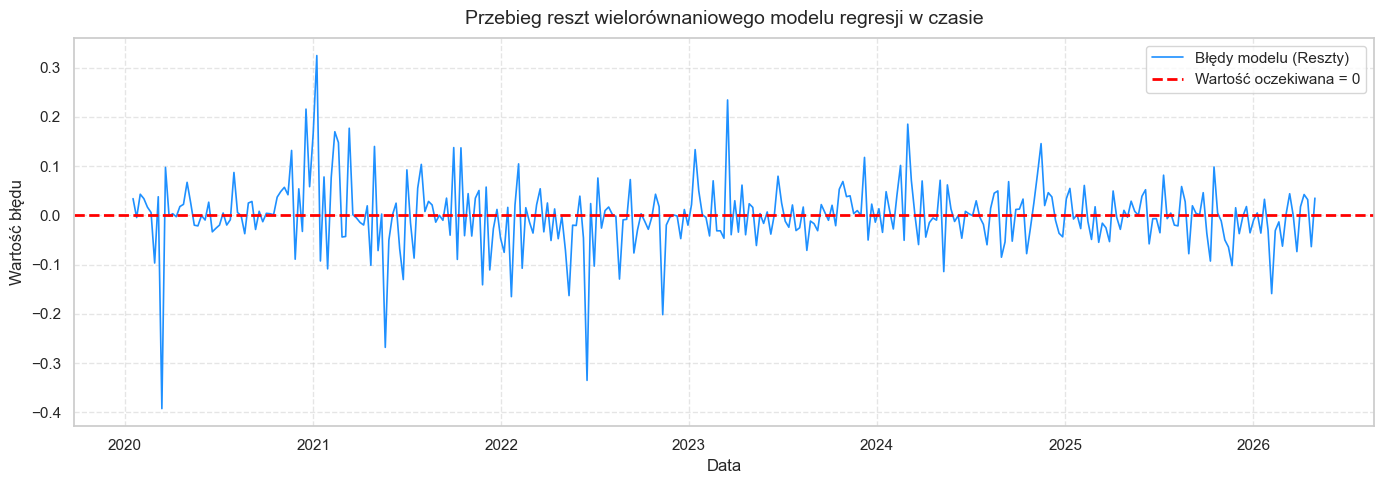

In [16]:
import matplotlib.pyplot as plt

print("Generowanie wykresu reszt modelu...")

# Wyciągamy reszty (błędy) z naszego estymowanego modelu
reszty = model.resid

plt.figure(figsize=(14, 5))
plt.plot(reszty.index, reszty, label='Błędy modelu (Reszty)', color='dodgerblue', linewidth=1.2)

# Dodajemy czerwoną linię na poziomie 0 (idealna wartość oczekiwana białego szumu)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Wartość oczekiwana = 0')

plt.title('Przebieg reszt wielorównaniowego modelu regresji w czasie', fontsize=14, pad=10)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Wartość błędu', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('przebieg_reszt.png', dpi=300)
plt.show()

In [20]:
import pandas as pd

# 1. Zebranie wszystkich surowych danych do jednej tymczasowej ramki
df_stats_raw = pd.concat([
    df_weekly_prices['Bitcoin'],
    df_weekly_prices['SP500'],
    df_weekly_prices['Zloto'],
    df_m2_weekly['M2'],
    df_hash_weekly['Hashrate'],
    df_fng_weekly['Fear_Greed']
], axis=1)

# 2. Usunięcie ewentualnych braków, aby statystyki dotyczyły dokładnie tego samego okresu
df_stats_raw = df_stats_raw.dropna()

# 3. Zmiana nazw kolumn na czytelne (zgodne z naszą Tabelą 1 w Wordzie)
df_stats_raw.columns = [
    'Bitcoin (USD)', 
    'S&P 500 (pkt)', 
    'Złoto (USD/oz)', 
    'M2 (mld USD)', 
    'Hashrate (EH/s)', 
    'Fear & Greed'
]

# 4. Obliczanie statystyk opisowych
statystyki = df_stats_raw.agg(['mean', 'std', 'min', 'max', 'skew', 'kurt']).T

# 5. Tłumaczenie nagłówków na język polski
statystyki.columns = ['Średnia', 'Odchylenie std.', 'Minimum', 'Maksimum', 'Skośność', 'Kurtoza']

# 6. Zaokrąglenie do 2 miejsc po przecinku dla czystości wydruku
statystyki = statystyki.round(2)

# 7. Wyświetlenie gotowej tabeli
print("--- STATYSTYKI OPISOWE DLA SUROWYCH ZMIENNYCH ---")
print(statystyki.to_string())

--- STATYSTYKI OPISOWE DLA SUROWYCH ZMIENNYCH ---
                      Średnia  Odchylenie std.      Minimum      Maksimum  Skośność  Kurtoza
Bitcoin (USD)    4.879462e+04     3.126680e+04      5563.71  1.222665e+05      0.60    -0.69
S&P 500 (pkt)    4.710780e+03     1.123060e+03      2304.92  7.209010e+03      0.44    -0.68
Złoto (USD/oz)   2.333510e+03     8.606700e+02      1484.00  5.230500e+03      1.72     2.05
M2 (mld USD)     2.073677e+04     1.559720e+03     15342.80  2.311390e+04     -1.69     2.86
Hashrate (EH/s)  4.337434e+08     3.199034e+08  82285031.36  1.267208e+09      0.75    -0.72
Fear & Greed     4.778000e+01     2.262000e+01         7.00  9.500000e+01      0.08    -1.09


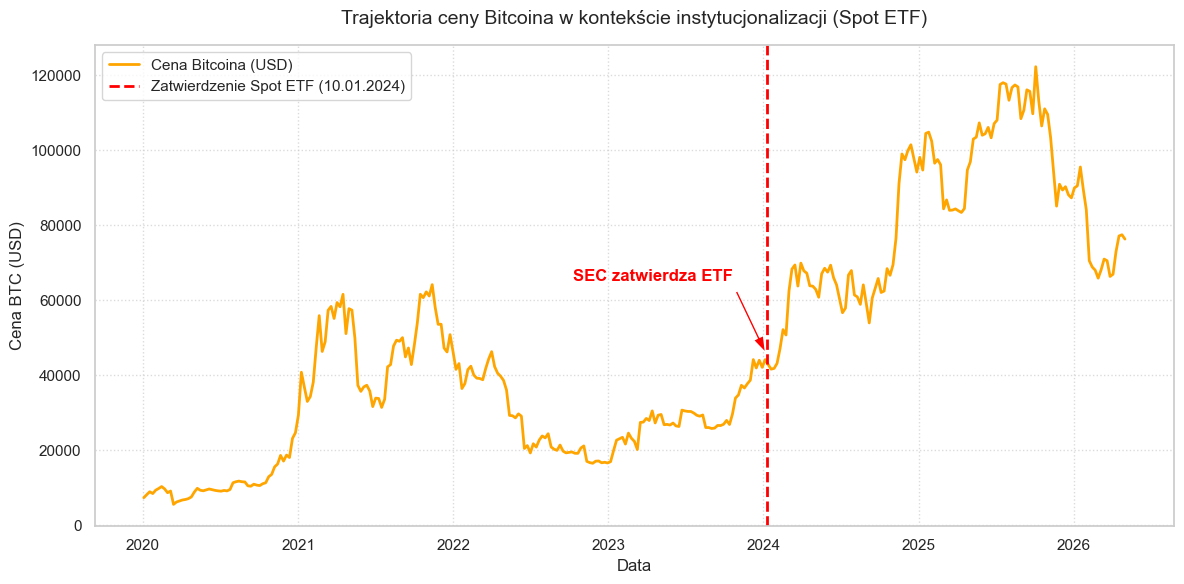

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Zakładam, że Pana dane historyczne są w df_weekly_prices['Bitcoin']
# Tworzymy wykres
plt.figure(figsize=(12, 6))

# Rysowanie linii ceny BTC
plt.plot(df_weekly_prices.index, df_weekly_prices['Bitcoin'], label='Cena Bitcoina (USD)', color='orange', linewidth=2)

# Zaznaczenie daty zatwierdzenia ETF (10 stycznia 2024)
etf_date = pd.to_datetime('2024-01-10')

# Dodanie pionowej czerwonej przerywanej linii
plt.axvline(x=etf_date, color='red', linestyle='--', linewidth=2, label='Zatwierdzenie Spot ETF (10.01.2024)')

# Dodanie strzałki i tekstu (adnotacji)
plt.annotate('SEC zatwierdza ETF', 
             xy=(etf_date, 45000), 
             xytext=(etf_date - pd.DateOffset(months=15), 65000),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=12, fontweight='bold', color='red')

# Formatowanie wykresu
plt.title('Trajektoria ceny Bitcoina w kontekście instytucjonalizacji (Spot ETF)', fontsize=14, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Cena BTC (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Zapis do pliku
plt.tight_layout()
plt.savefig('ETFY.png', dpi=300)
plt.show()